<a href="https://colab.research.google.com/github/Earlene33/Analisis-data/blob/main/Analisis_dan_Visualisasi_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
data = pd.read_csv('data_praktikum.csv')
print(data.head())
print(data.info())
print(data.isnull().sum())

   Order_ID  CustomerID  Order_Date Product_Category  Quantity  \
0      1001        5039  2023-08-19            Books         4   
1      1002        5029  2023-08-29          Fashion         5   
2      1003        5015  2023-02-21          Fashion         4   
3      1004        5043  2023-04-06          Fashion         2   
4      1005        5008  2023-08-10       Home Decor         2   

   Price_Per_Unit  Ad_Budget  Total_Sales  
0       1184000.0   982000.0    4736000.0  
1       1733000.0  3513000.0    8665000.0  
2       1767000.0  2117000.0    7068000.0  
3        512000.0  4384000.0    1024000.0  
4       1820000.0  2625000.0    3640000.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          150 non-null    int64  
 1   CustomerID        150 non-null    int64  
 2   Order_Date        150 non-null    object 


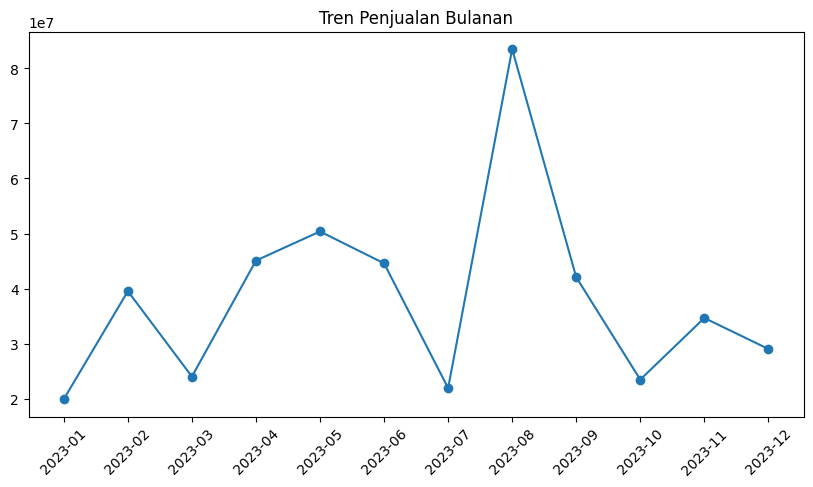

In [24]:
data['Order_Date'] = pd.to_datetime(data['Order_Date'])
data['Month'] = data['Order_Date'].dt.to_period('M').astype(str)

monthly_sales = data.groupby('Month')['Total_Sales'].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title('Tren Penjualan Bulanan')
plt.xticks(rotation=45)
plt.show()

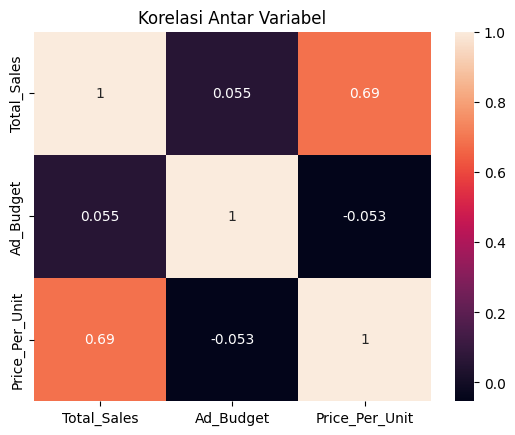

In [25]:
## Heatmap ##
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data_praktikum.csv')

correlation = df[['Total_Sales', 'Ad_Budget', 'Price_Per_Unit']].corr()

sns.heatmap(correlation, annot=True)
plt.title('Korelasi Antar Variabel')
plt.show()

**Tugas** **Sebangku**

1. Identifikasi Produk "Underperformer"

   Order_ID  CustomerID  Order_Date Product_Category  Quantity  \
0      1001        5039  2023-08-19            Books         4   
1      1002        5029  2023-08-29          Fashion         5   
2      1003        5015  2023-02-21          Fashion         4   
3      1004        5043  2023-04-06          Fashion         2   
4      1005        5008  2023-08-10       Home Decor         2   

   Price_Per_Unit  Ad_Budget  Total_Sales  
0       1184000.0   982000.0    4736000.0  
1       1733000.0  3513000.0    8665000.0  
2       1767000.0  2117000.0    7068000.0  
3        512000.0  4384000.0    1024000.0  
4       1820000.0  2625000.0    3640000.0  
Product_Category
Gadget         31
Home Decor     39
Fashion        45
Books          48
Electronics    55
Name: Quantity, dtype: int64


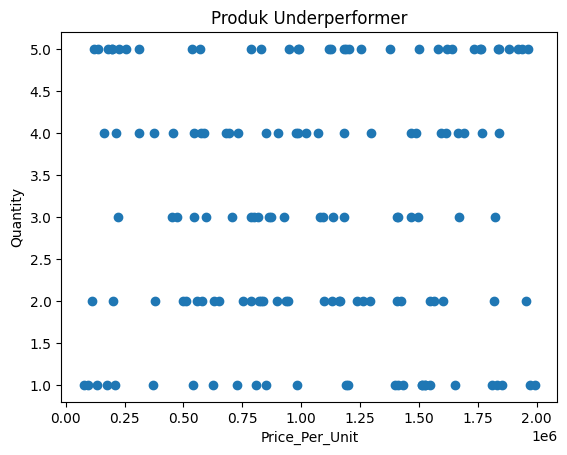

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data_praktikum.csv')

print(df.head())

df = df.dropna()
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

avg_price = df['Price_Per_Unit'].mean()

produk_mahal = df[df['Price_Per_Unit'] > avg_price]

underperformer = produk_mahal.groupby('Product_Category')['Quantity'].sum().sort_values()

print(underperformer.head())

plt.scatter(df['Price_Per_Unit'], df['Quantity'])
plt.xlabel('Price_Per_Unit')
plt.ylabel('Quantity')
plt.title('Produk Underperformer')
plt.show()

2. Segmentasi Pelanggan (RFM Analysis)


In [27]:
df = df.dropna()
df['Order_Date'] = pd.to_datetime(df['Order_Date'])


In [28]:
import datetime as dt

# Ambil tanggal terakhir dalam data
today = df['Order_Date'].max()

# Hitung RFM
rfm = df.groupby('CustomerID').agg({
    'Order_Date': lambda x: (today - x.max()).days,  # Recency
    'Order_ID': 'count',                            # Frequency
    'Total_Sales': 'sum'                            # Monetary
})

# Rename kolom
rfm.columns = ['Recency', 'Frequency', 'Monetary']

print(rfm.head())

rfm_sorted = rfm.sort_values(by=['Monetary', 'Frequency'], ascending=False)
print(rfm_sorted.head())

            Recency  Frequency    Monetary
CustomerID                                
5001            212          4   8562000.0
5002             76          3   6931000.0
5003            117          3   9433000.0
5004            195          2  15368000.0
5005             22          2   9105000.0
            Recency  Frequency    Monetary
CustomerID                                
5015            106          5  26309000.0
5008             14          6  22350000.0
5035             52          6  22066000.0
5014             53          6  20797000.0
5044             17          7  20631000.0


3. Analisis Kontribusi Kategori


In [29]:
# Kelompokkan berdasarkan kategori
category = df.groupby('Product_Category').agg({
    'Total_Sales': 'sum',
    'Ad_Budget': 'sum'
})

# Hitung efisiensi
category['Efisiensi'] = category['Total_Sales'] / category['Ad_Budget']

# Urutkan dari paling tidak efisien
category = category.sort_values('Efisiensi')

print(category)

                  Total_Sales   Ad_Budget  Efisiensi
Product_Category                                    
Gadget             70523000.0  68765000.0   1.025565
Home Decor         69340000.0  59227000.0   1.170750
Fashion            96550000.0  77768000.0   1.241513
Books             107569000.0  84208000.0   1.277420
Electronics       114095000.0  79264000.0   1.439430


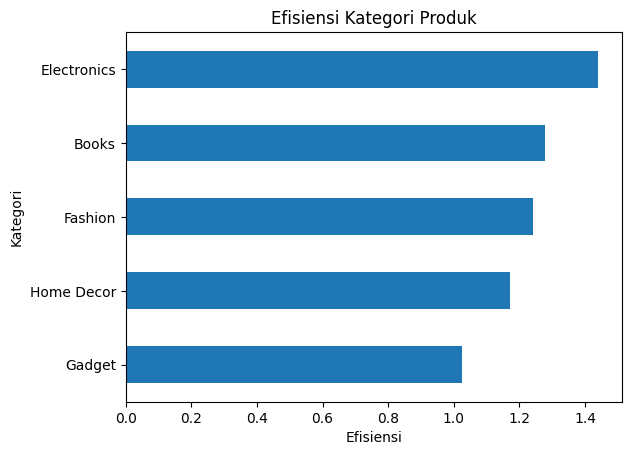

In [30]:
import matplotlib.pyplot as plt

category['Efisiensi'].plot(kind='barh')
plt.title('Efisiensi Kategori Produk')
plt.xlabel('Efisiensi')
plt.ylabel('Kategori')
plt.show()

4. Uji Hipotesis Sederhana


In [31]:
# Hitung median iklan
median_ads = df['Ad_Budget'].median()

# Kelompok iklan tinggi
high_ads = df[df['Ad_Budget'] > median_ads]

# Kelompok iklan rendah
low_ads = df[df['Ad_Budget'] <= median_ads]

print("Rata-rata penjualan (Iklan Tinggi):", high_ads['Total_Sales'].mean())
print("Rata-rata penjualan (Iklan Rendah):", low_ads['Total_Sales'].mean())

Rata-rata penjualan (Iklan Tinggi): 3114126.76056338
Rata-rata penjualan (Iklan Rendah): 3291305.5555555555


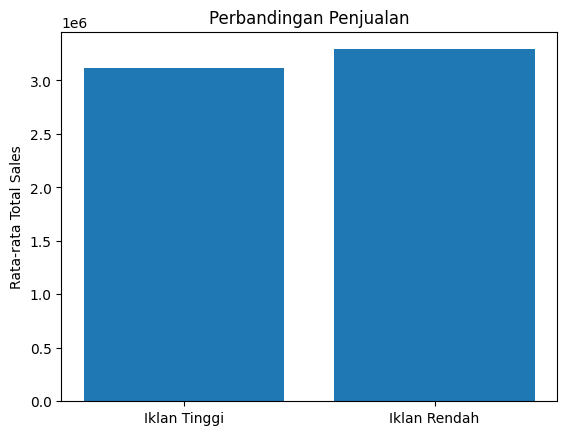

In [32]:
import matplotlib.pyplot as plt

labels = ['Iklan Tinggi', 'Iklan Rendah']
values = [
    high_ads['Total_Sales'].mean(),
    low_ads['Total_Sales'].mean()
]

plt.bar(labels, values)
plt.title('Perbandingan Penjualan')
plt.ylabel('Rata-rata Total Sales')
plt.show()

5. Pendalaman Teknik: RFM Analysis


In [33]:
import datetime as dt
import pandas as pd

# Tentukan snapshot date (hari setelah transaksi terakhir)
snapshot_date = df['Order_Date'].max() + dt.timedelta(days=1)

# Hitung RFM
rfm = df.groupby('CustomerID').agg({
    'Order_Date': lambda x: (snapshot_date - x.max()).days,
    'Order_ID': 'count',
    'Total_Sales': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Ranking dulu biar aman dari error
rfm['R_rank'] = rfm['Recency'].rank(method='first')
rfm['F_rank'] = rfm['Frequency'].rank(method='first')
rfm['M_rank'] = rfm['Monetary'].rank(method='first')

# Bagi jadi 5 kelompok
rfm['R_Score'] = pd.qcut(rfm['R_rank'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['F_rank'], 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['M_rank'], 5, labels=[1,2,3,4,5])

# Gabungkan skor
rfm['RFM_Group'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

print(rfm.head())

            Recency  Frequency    Monetary  R_rank  F_rank  M_rank R_Score  \
CustomerID                                                                   
5001            213          4   8562000.0    40.0    34.0    26.0       1   
5002             77          3   6931000.0    20.0    21.0    22.0       3   
5003            118          3   9433000.0    26.0    22.0    29.0       3   
5004            196          2  15368000.0    36.0    12.0    38.0       2   
5005             23          2   9105000.0     8.0    13.0    27.0       5   

           F_Score M_Score RFM_Group  
CustomerID                            
5001             4       3       143  
5002             3       3       333  
5003             3       3       333  
5004             2       4       224  
5005             2       3       523  


6. Regresi Linear Sederhana (Pengaruh Iklan ke Penjualan)

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Tentukan fitur (X) dan target (y)
X = df[['Ad_Budget']]
y = df['Total_Sales']

# Split data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Buat model
model = LinearRegression()

# Latih model
model.fit(X_train, y_train)

# Hasil
print("Koefisien Iklan:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R2 Score:", model.score(X_test, y_test))

Koefisien Iklan: 0.1841982749623798
Intercept: 2496138.8285295684
R2 Score: -0.1956467472142791


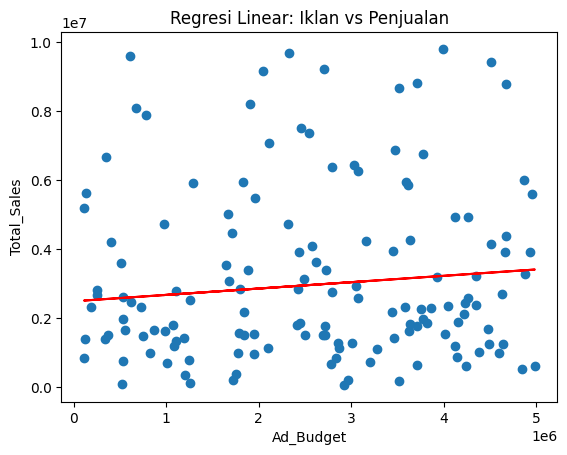

In [35]:
import matplotlib.pyplot as plt

plt.scatter(X, y)
plt.plot(X, model.predict(X), color='red')
plt.xlabel('Ad_Budget')
plt.ylabel('Total_Sales')
plt.title('Regresi Linear: Iklan vs Penjualan')
plt.show()